# AMD Screening Case Study

This notebook presents the two case studies accompanying the AMD screening feature paper.
It demonstrates how Average Minimum Distance (AMD) and Pointwise Distance Distribution
(PDD/EMD) metrics can be used to detect duplicate and similar crystal structures across
and within databases.

**Case Study 1 — Cross-database deduplication**  
Compare structures retrieved from the Materials Project (MP) and the Crystallography Open
Database (COD) to identify entries that describe the same or very similar crystal.

**Case Study 2 — Within-database similarity screening**  
Screen OQMD structures to discover groups of identical, very similar, and merely similar
entries and rank candidates by geometric diversity.

---
**Reproducibility note (Online Methods)**  
All CIF files used in these case studies are stored in the repository under:
```
tests/fixtures/cif_files/mp/     (12 structures)
tests/fixtures/cif_files/cod/    (20 structures)
tests/fixtures/cif_files/oqmd/   (39 structures)
```
No external downloads or API keys are required to reproduce the results.

In [ ]:
import sys
import json
from pathlib import Path

import amd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display

# Locate workspace root automatically
workspace_root = Path.cwd().resolve()
while workspace_root != workspace_root.parent:
    if (workspace_root / 'Features').is_dir() and (workspace_root / 'Information_Units').is_dir():
        break
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from Information_Units.Predictors.Pdd.PddPredictor import PddPredictor

# Fixture directories (relative to workspace root)
CIF_MP   = workspace_root / 'tests' / 'fixtures' / 'cif_files' / 'mp'
CIF_COD  = workspace_root / 'tests' / 'fixtures' / 'cif_files' / 'cod'
CIF_OQMD = workspace_root / 'tests' / 'fixtures' / 'cif_files' / 'oqmd'


class NotebookLogger:
    def log(self, message, level='info'):
        tag = level.upper().ljust(7)
        print(f'[{tag}] {message}')


logger = NotebookLogger()
print(f'Workspace root : {workspace_root}')
print(f'MP  CIF files  : {len(list(CIF_MP.glob("*.cif")))}')
print(f'COD CIF files  : {len(list(CIF_COD.glob("*.cif")))}')
print(f'OQMD CIF files : {len(list(CIF_OQMD.glob("*.cif")))}')

Workspace root : /home/soe/EMOS
MP  CIF files  : 12
COD CIF files  : 20
OQMD CIF files : 39


## Shared helpers

In [ ]:
def load_cif_files(directory: Path):
    """Return a list of (filename, cif_path) for all .cif files in a directory."""
    return sorted(
        [(p.stem, p) for p in directory.glob('*.cif')],
        key=lambda x: x[0],
    )


def run_amd(cif_paths, k=100, metric='chebyshev', logger=None):
    """Run PddPredictor and adapt its descriptors to the notebook pairwise schema."""
    predictor = PddPredictor(predictor_name='pdd_notebook', k=k, logger=logger)
    cif_paths = list(cif_paths)
    cif_texts = [path.read_text(encoding='utf-8') for path in cif_paths]
    pdd_result = predictor.predict(cif_texts)
    pdd_items = pdd_result.get('results', [])
    successful = [item for item in pdd_items if item.get('status') == 'ok']

    if len(successful) < 2:
        error = f'Only {len(successful)} of {len(cif_paths)} CIF files produced valid PDD results.'
        return {'results': [{'status': 'error', 'error': error}]}

    amd_vectors = [
        np.asarray(item['properties']['pdd_vector'], dtype=float)
        for item in successful
    ]
    pdd_matrices = [
        np.asarray(item['properties']['pdd_matrix'], dtype=float)
        for item in successful
    ]
    amd_matrix = amd.AMD_cdist(amd_vectors, amd_vectors, metric=metric)

    pairwise_distances = []
    for i in range(len(successful)):
        for j in range(i + 1, len(successful)):
            pdd_emd = float(amd.EMD(pdd_matrices[i], pdd_matrices[j]))
            amd_dist = float(amd_matrix[i, j])
            pairwise_distances.append({
                'crystal_1_file': str(cif_paths[successful[i]['index']]),
                'crystal_2_file': str(cif_paths[successful[j]['index']]),
                'pdd_emd_distance': pdd_emd,
                'amd_distance': amd_dist,
                'identical': pdd_emd < 1e-6,
                'very_similar': pdd_emd < 0.1,
                'similar': pdd_emd < 0.5,
            })

    return {
        'results': [{
            'status': 'success',
            'properties': {'pairwise_distances': pairwise_distances},
        }],
    }


def pairwise_to_df(result, name_map=None):
    """
    Convert AMD result dict to a tidy DataFrame of pairwise distances.

    Parameters
    ----------
    result : dict
        Output from run_amd().
    name_map : dict, optional
        Mapping from file path string to display label.

    Returns
    -------
    pd.DataFrame
    """
    first = (result.get('results') or [{}])[0]
    if first.get('status') != 'success':
        raise RuntimeError(f'AMD prediction failed: {first.get("error")}')

    rows = []
    for pair in first['properties']['pairwise_distances']:
        if 'error' in pair:
            continue
        path1 = pair['crystal_1_file']
        path2 = pair['crystal_2_file']
        label1 = name_map.get(path1, Path(path1).stem) if name_map else Path(path1).stem
        label2 = name_map.get(path2, Path(path2).stem) if name_map else Path(path2).stem
        rows.append({
            'structure_1': label1,
            'structure_2': label2,
            'pdd_emd': pair['pdd_emd_distance'],
            'amd_dist': pair['amd_distance'],
            'identical':    pair.get('identical', False),
            'very_similar': pair.get('very_similar', False),
            'similar':      pair.get('similar', False),
        })
    return pd.DataFrame(rows)

---
## Case Study 1 — Cross-database Deduplication: MP vs COD

Both the Materials Project and the COD archive crystal structures from the experimental and
computational literature. The same compound is frequently deposited in both databases under
different identifiers, in different settings, or with slight numerical differences.

This case study shows that AMD screening reliably identifies these duplicates without
requiring element-type information, formula matching, or space-group comparison.

**Setup**: 12 MP structures + 20 COD structures = 32 total, 496 pairwise comparisons.

In [8]:
mp_entries  = load_cif_files(CIF_MP)
cod_entries = load_cif_files(CIF_COD)

all_cs1_entries = mp_entries + cod_entries
all_cs1_paths   = [p for _, p in all_cs1_entries]
cs1_name_map    = {str(p): name for name, p in all_cs1_entries}
cs1_labels      = [name for name, _ in all_cs1_entries]

print(f'MP structures  : {len(mp_entries)}')
print(f'COD structures : {len(cod_entries)}')
print(f'Total          : {len(all_cs1_entries)}')
print(f'Expected pairs : {len(all_cs1_entries) * (len(all_cs1_entries) - 1) // 2}')

MP structures  : 12
COD structures : 20
Total          : 32
Expected pairs : 496


In [9]:
print('Running AMD screening on Case Study 1 (MP vs COD)...')
cs1_result = run_amd(all_cs1_paths, k=100, metric='chebyshev', logger=logger)
cs1_df = pairwise_to_df(cs1_result, name_map=cs1_name_map)

print(f'\nSuccessfully computed {len(cs1_df)} pairwise distances.')
cs1_df.head()

Running AMD screening on Case Study 1 (MP vs COD)...
[INFO   ] PDD prediction starting: 32 CIF string(s), k=100
[INFO   ] item[0]: PDD computed — shape (2×100)
[INFO   ] item[1]: PDD computed — shape (2×100)
[INFO   ] item[2]: PDD computed — shape (80×100)
[INFO   ] item[3]: PDD computed — shape (80×100)
[INFO   ] item[4]: PDD computed — shape (80×100)
[INFO   ] item[5]: PDD computed — shape (80×100)
[INFO   ] item[6]: PDD computed — shape (1×100)
[INFO   ] item[7]: PDD computed — shape (1×100)
[INFO   ] item[8]: PDD computed — shape (1×100)
[INFO   ] item[9]: PDD computed — shape (1×100)
[INFO   ] item[10]: PDD computed — shape (2×100)
[INFO   ] item[11]: PDD computed — shape (7×100)
[INFO   ] item[12]: PDD computed — shape (1×100)
[INFO   ] item[13]: PDD computed — shape (1×100)
[INFO   ] item[14]: PDD computed — shape (1×100)
[INFO   ] item[15]: PDD computed — shape (9×100)
[INFO   ] item[16]: PDD computed — shape (1×100)
[INFO   ] item[17]: PDD computed — shape (1×100)
[INFO   ] it

KeyError: 'pdd_emd_matrix'

In [ ]:
print_summary('Case Study 1 — Cross-database Deduplication (MP vs COD)', cs1_df)


=== Case Study 1 — Cross-database Deduplication (MP vs COD) ===
Total pairs compared   : 465
Identical    (PDD < 1e-6) : 0
Very similar (PDD < 0.10) : 65
Similar      (PDD < 0.50) : 83
Distinct     (PDD >= 0.50): 317

Closest pairs (PDD/EMD < 0.5):


,structure_1,structure_2,pdd_emd,amd_dist,identical,very_similar
464,cod-9008877,cod-9011662,0.001000,0.001000,False,True
393,cod-2300112,cod-9004178,0.002409,0.002409,False,True
451,cod-9004178,cod-9004180,0.004683,0.004683,False,True
395,cod-2300112,cod-9004180,0.005281,0.005281,False,True
394,cod-2300112,cod-9004179,0.007800,0.007800,False,True
450,cod-9004178,cod-9004179,0.007800,0.007800,False,True
455,cod-9004179,cod-9004180,0.009518,0.009518,False,True
441,cod-2300450,cod-9004181,0.009627,0.009627,False,True
375,cod-2107059,cod-2300113,0.015000,0.015000,False,True
439,cod-2300450,cod-9004179,0.016580,0.016580,False,True


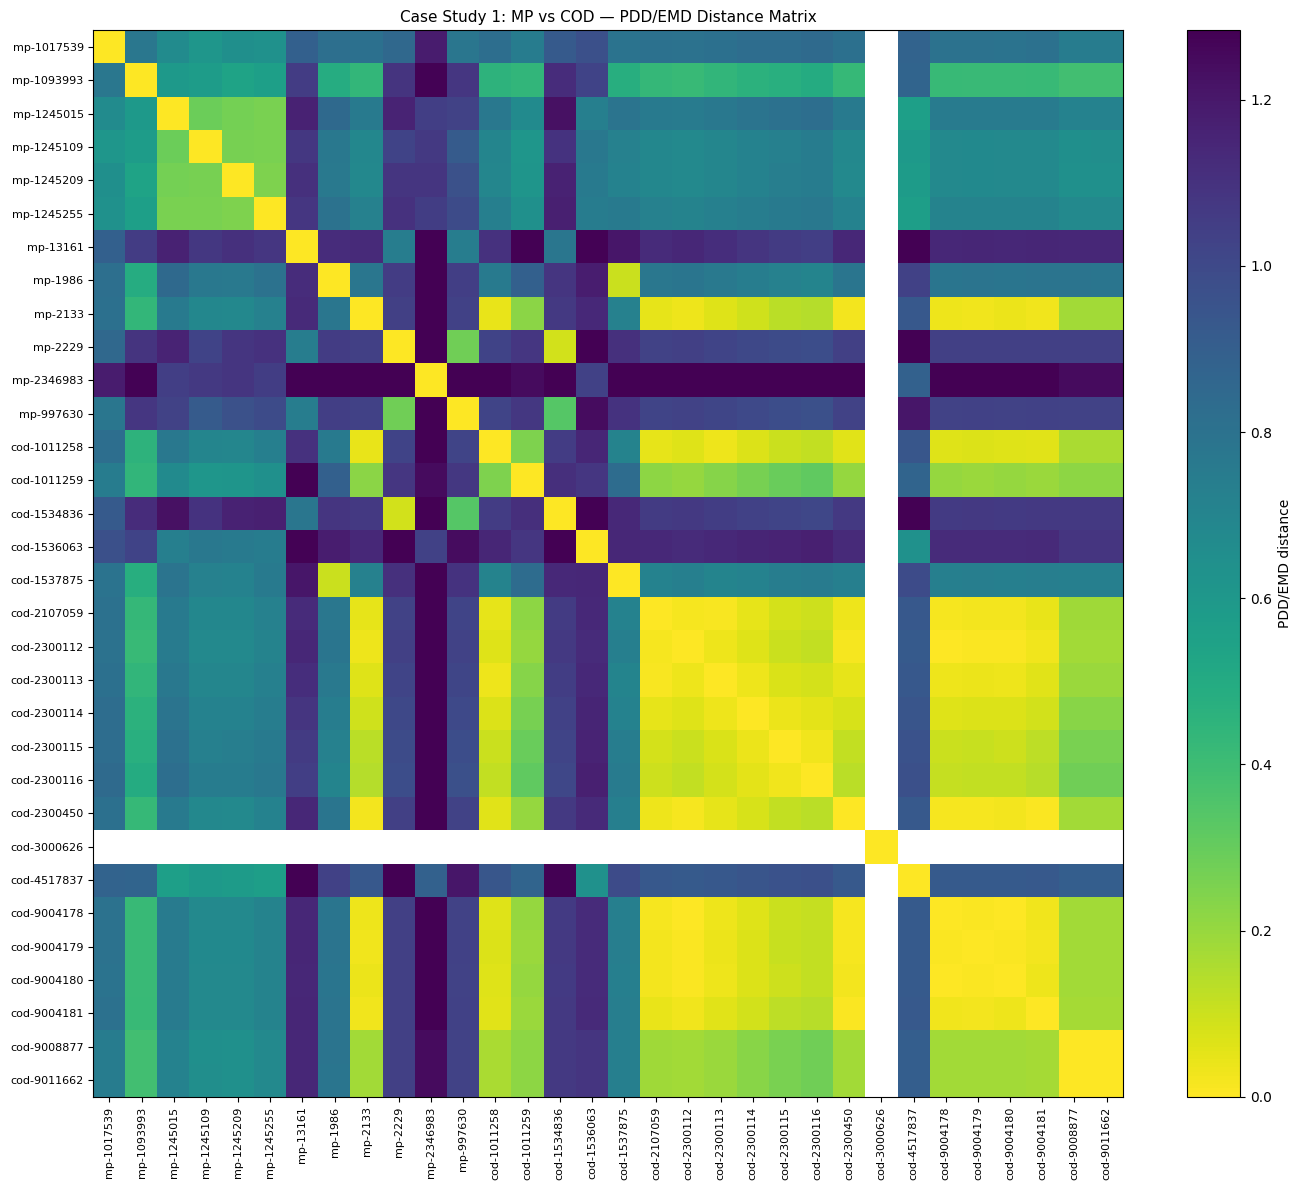

In [ ]:
cs1_matrix = build_distance_matrix(cs1_df, cs1_labels)
plot_distance_matrix(
    cs1_matrix, cs1_labels,
    title='Case Study 1: MP vs COD — PDD/EMD Distance Matrix',
    figsize=(14, 12),
)

### Cross-database pairs only

The diagonal blocks (MP–MP and COD–COD) may contain near-duplicates within the same
database. The off-diagonal block shows which MP entries are geometrically equivalent to COD
entries — these are the true cross-database duplicates.

In [ ]:
mp_names  = {name for name, _ in mp_entries}
cod_names = {name for name, _ in cod_entries}

cross_df = cs1_df[
    (cs1_df['structure_1'].isin(mp_names) & cs1_df['structure_2'].isin(cod_names)) |
    (cs1_df['structure_1'].isin(cod_names) & cs1_df['structure_2'].isin(mp_names))
].copy()

cross_close = cross_df[cross_df['pdd_emd'] < 0.5].sort_values('pdd_emd')

print(f'Cross-database pairs total  : {len(cross_df)}')
print(f'Cross-database identical    : {cross_df["identical"].sum()}')
print(f'Cross-database very similar : {(cross_df["very_similar"] & ~cross_df["identical"]).sum()}')
print(f'Cross-database similar      : {(cross_df["similar"] & ~cross_df["very_similar"]).sum()}')

if not cross_close.empty:
    print('\nClosest cross-database pairs (PDD/EMD < 0.5):')
    display(cross_close[['structure_1', 'structure_2', 'pdd_emd', 'amd_dist', 'identical', 'very_similar']].head(15))

Cross-database pairs total  : 228
Cross-database identical    : 0
Cross-database very similar : 11
Cross-database similar      : 23

Closest cross-database pairs (PDD/EMD < 0.5):


,structure_1,structure_2,pdd_emd,amd_dist,identical,very_similar
226,mp-2133,cod-2300450,0.021469,0.021469,False,True
229,mp-2133,cod-9004179,0.029453,0.029453,False,True
231,mp-2133,cod-9004181,0.029453,0.029453,False,True
221,mp-2133,cod-2300112,0.031127,0.031127,False,True
228,mp-2133,cod-9004178,0.031787,0.031787,False,True
230,mp-2133,cod-9004180,0.036244,0.036244,False,True
215,mp-2133,cod-1011258,0.044554,0.044554,False,True
220,mp-2133,cod-2107059,0.049452,0.049452,False,True
222,mp-2133,cod-2300113,0.062833,0.062833,False,True
238,mp-2229,cod-1534836,0.088326,0.088326,False,True


---
## Case Study 2 — Within-database Similarity Screening: OQMD

Large databases such as OQMD contain many structurally related entries — sometimes the
same compound in different settings, ionic variants of a prototype, or slightly distorted
polymorphs. Identifying these groups before a downstream workflow avoids redundant
calculations and biased statistics.

This case study uses AMD screening to partition 39 OQMD structures into groups of
identical, very similar, and similar entries, and ranks candidates by geometric novelty
(i.e. maximum minimum distance to any other candidate).

**Setup**: 39 OQMD structures → 741 pairwise comparisons.

In [ ]:
oqmd_entries = load_cif_files(CIF_OQMD)
oqmd_paths   = [p for _, p in oqmd_entries]
oqmd_name_map = {str(p): name for name, p in oqmd_entries}
oqmd_labels  = [name for name, _ in oqmd_entries]

print(f'OQMD structures : {len(oqmd_entries)}')
print(f'Expected pairs  : {len(oqmd_entries) * (len(oqmd_entries) - 1) // 2}')

OQMD structures : 39
Expected pairs  : 741


In [ ]:
print('Running AMD screening on Case Study 2 (OQMD within-database)...')
cs2_result = run_amd(oqmd_paths, k=100, metric='chebyshev', logger=logger)
cs2_df = pairwise_to_df(cs2_result, name_map=oqmd_name_map)

print(f'\nSuccessfully computed {len(cs2_df)} pairwise distances.')
cs2_df.head()

Running AMD screening on Case Study 2 (OQMD within-database)...
[INFO   ] PDD prediction starting: 39 CIF string(s), k=100
[INFO   ] item[0]: PDD computed — shape (1×100)
[INFO   ] item[1]: PDD computed — shape (2×100)
[INFO   ] item[2]: PDD computed — shape (1×100)
[INFO   ] item[3]: PDD computed — shape (1×100)
[INFO   ] item[4]: PDD computed — shape (1×100)
[INFO   ] item[5]: PDD computed — shape (1×100)
[INFO   ] item[6]: PDD computed — shape (2×100)
[INFO   ] item[7]: PDD computed — shape (1×100)
[INFO   ] item[8]: PDD computed — shape (2×100)
[INFO   ] item[9]: PDD computed — shape (1×100)
[INFO   ] item[10]: PDD computed — shape (1×100)
[INFO   ] item[11]: PDD computed — shape (2×100)
[INFO   ] item[12]: PDD computed — shape (1×100)
[INFO   ] item[13]: PDD computed — shape (1×100)
[INFO   ] item[14]: PDD computed — shape (1×100)
[INFO   ] item[15]: PDD computed — shape (1×100)
[INFO   ] item[16]: PDD computed — shape (2×100)
[INFO   ] item[17]: PDD computed — shape (1×100)
[INFO

,structure_1,structure_2,pdd_emd,amd_dist,identical,very_similar,similar
0,oqmd-1106917,oqmd-116025,0.687082,0.687082,False,False,False
1,oqmd-1106917,oqmd-117131,0.733108,0.733108,False,False,False
2,oqmd-1106917,oqmd-1223683,1.094276,1.094276,False,False,False
3,oqmd-1106917,oqmd-1230655,0.606121,0.606121,False,False,False
4,oqmd-1106917,oqmd-1343236,0.003129,0.003129,False,True,True


In [ ]:
print_summary('Case Study 2 — Within-database Screening (OQMD)', cs2_df)


=== Case Study 2 — Within-database Screening (OQMD) ===
Total pairs compared   : 741
Identical    (PDD < 1e-6) : 0
Very similar (PDD < 0.10) : 46
Similar      (PDD < 0.50) : 67
Distinct     (PDD >= 0.50): 628

Closest pairs (PDD/EMD < 0.5):


,structure_1,structure_2,pdd_emd,amd_dist,identical,very_similar
9,oqmd-1106917,oqmd-1442030,0.000114,0.000114,False,True
551,oqmd-1479504,oqmd-1479511,0.000786,0.000379,False,True
189,oqmd-1343236,oqmd-1472687,0.001142,0.001142,False,True
191,oqmd-1343236,oqmd-1473257,0.001280,0.001280,False,True
461,oqmd-1444341,oqmd-328816,0.001317,0.001317,False,True
339,oqmd-1442030,oqmd-1472687,0.001873,0.001873,False,True
14,oqmd-1106917,oqmd-1472687,0.001986,0.001986,False,True
737,oqmd-328816,oqmd-6958,0.002207,0.002207,False,True
106,oqmd-117131,oqmd-307732,0.002395,0.002395,False,True
466,oqmd-1472687,oqmd-1473257,0.002423,0.002423,False,True


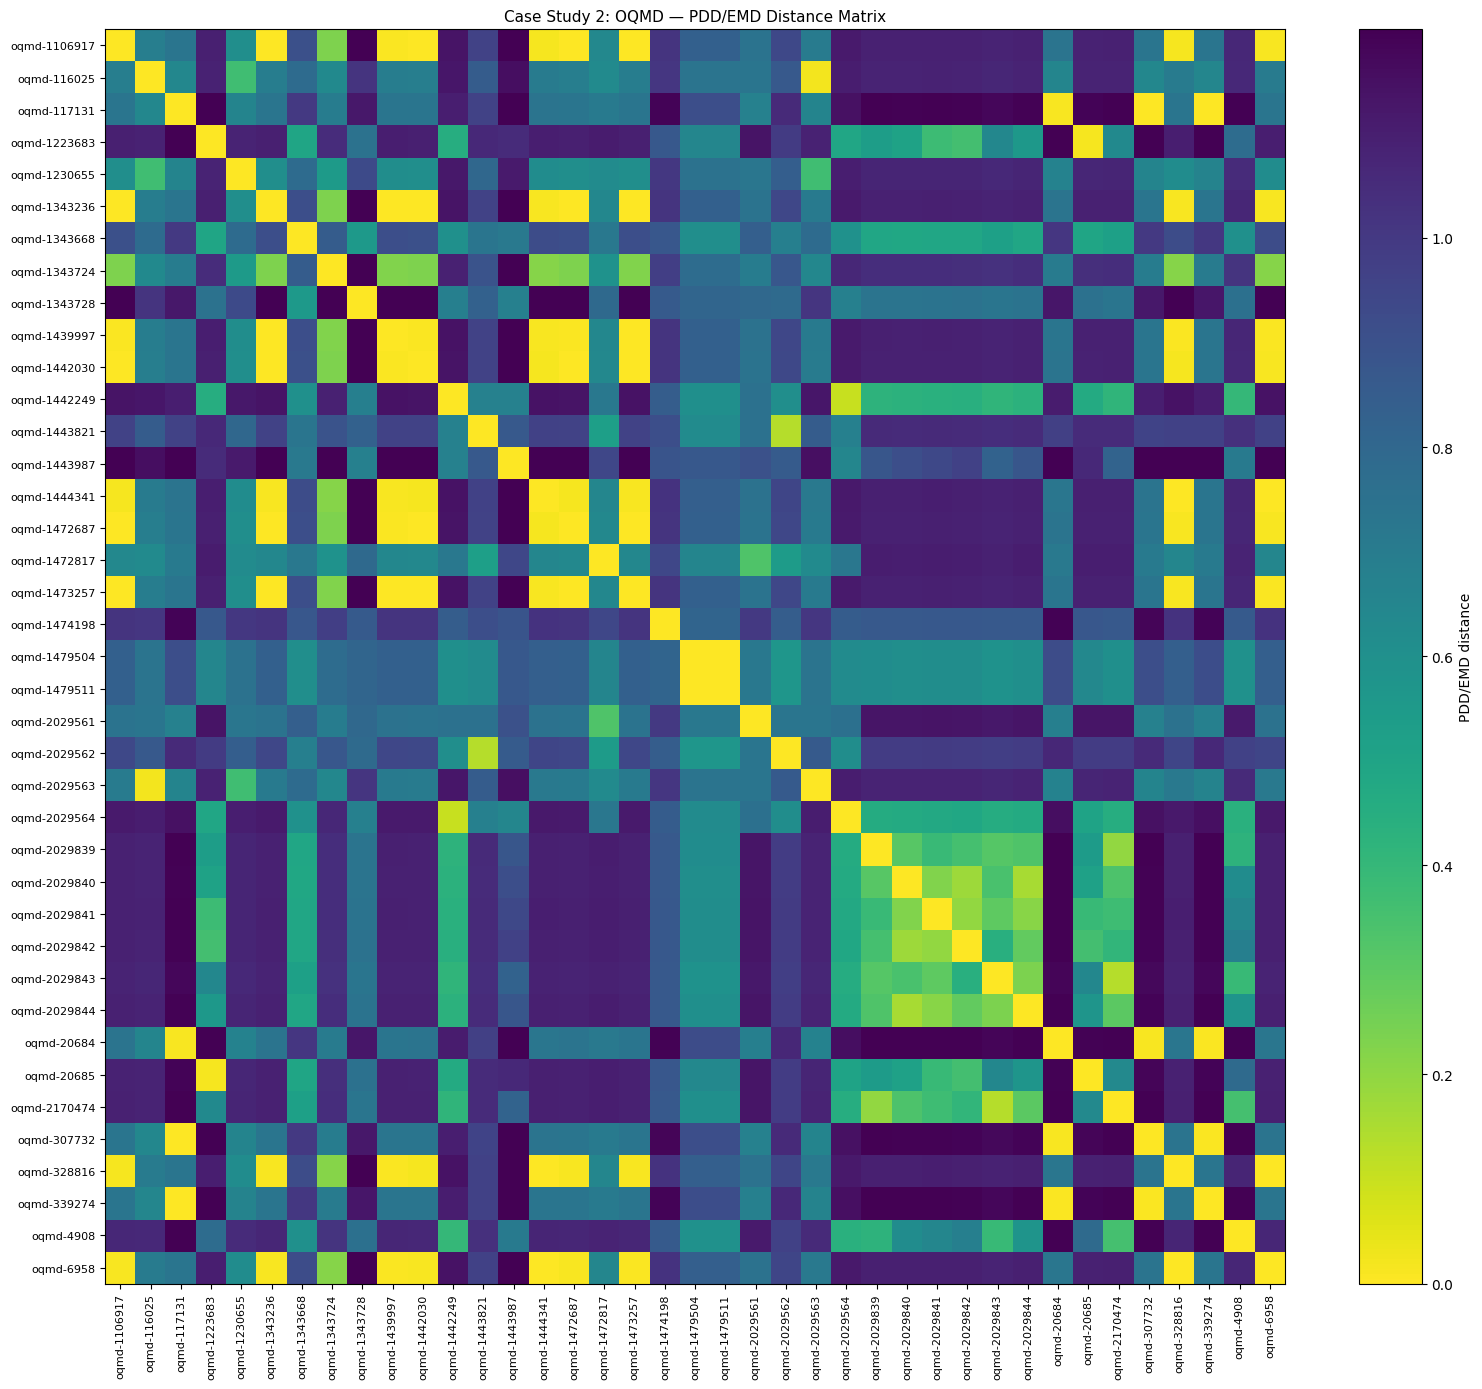

In [ ]:
cs2_matrix = build_distance_matrix(cs2_df, oqmd_labels)
plot_distance_matrix(
    cs2_matrix, oqmd_labels,
    title='Case Study 2: OQMD — PDD/EMD Distance Matrix',
    figsize=(16, 14),
)

### Diversity ranking

A structure is considered *geometrically diverse* if its minimum PDD/EMD distance to any
other structure in the set is large. The ranking below can be used to select a maximally
diverse subset, e.g. as the seed set for an active-learning campaign.

Diversity ranking (most geometrically distinct structures first):


,structure,min_pdd_emd_to_others
0,oqmd-1474198,0.814745
1,oqmd-1443987,0.651032
2,oqmd-1343728,0.548387
3,oqmd-1343668,0.485522
4,oqmd-1230655,0.365560
5,oqmd-4908,0.351514
6,oqmd-2029561,0.328610
7,oqmd-1472817,0.328610
8,oqmd-1343724,0.216642
9,oqmd-2029839,0.195679


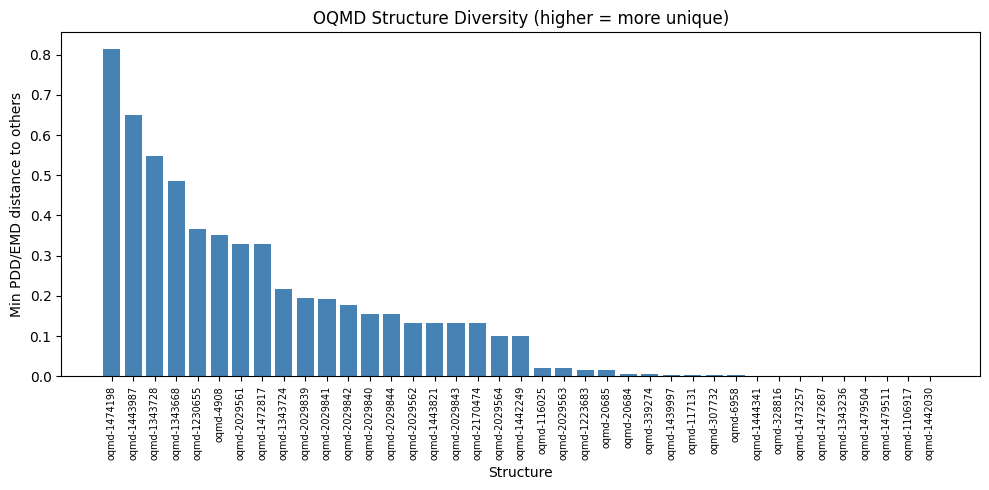

In [ ]:
# For each structure, compute its minimum distance to all other structures
min_dists = {}
for label in oqmd_labels:
    partner_distances = cs2_df[
        (cs2_df['structure_1'] == label) | (cs2_df['structure_2'] == label)
    ]['pdd_emd'].values
    # Exclude self-comparisons (distance = 0)
    non_zero = partner_distances[partner_distances > 1e-9]
    min_dists[label] = float(np.min(non_zero)) if non_zero.size > 0 else 0.0

diversity_df = pd.DataFrame([
    {'structure': k, 'min_pdd_emd_to_others': v}
    for k, v in min_dists.items()
]).sort_values('min_pdd_emd_to_others', ascending=False).reset_index(drop=True)

print('Diversity ranking (most geometrically distinct structures first):')
display(diversity_df.head(20))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(diversity_df)), diversity_df['min_pdd_emd_to_others'], color='steelblue')
ax.set_xticks(range(len(diversity_df)))
ax.set_xticklabels(diversity_df['structure'], rotation=90, fontsize=7)
ax.set_xlabel('Structure')
ax.set_ylabel('Min PDD/EMD distance to others')
ax.set_title('OQMD Structure Diversity (higher = more unique)')
plt.tight_layout()
plt.show()

### Similarity clusters

Structures with PDD/EMD < 0.1 are grouped into clusters. Each cluster represents a set of
very similar (or identical) entries that could be treated as a single representative in
downstream computations.

In [ ]:
from collections import defaultdict

SIMILARITY_THRESHOLD = 0.1  # PDD/EMD threshold for "very similar"

# Build adjacency using union-find
parent = {label: label for label in oqmd_labels}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    px, py = find(x), find(y)
    if px != py:
        parent[px] = py

for _, row in cs2_df[cs2_df['pdd_emd'] < SIMILARITY_THRESHOLD].iterrows():
    union(row['structure_1'], row['structure_2'])

clusters = defaultdict(list)
for label in oqmd_labels:
    clusters[find(label)].append(label)

cluster_list = sorted(clusters.values(), key=len, reverse=True)

print(f'Similarity threshold (PDD/EMD) : {SIMILARITY_THRESHOLD}')
print(f'Total structures               : {len(oqmd_labels)}')
print(f'Number of clusters             : {len(cluster_list)}')
print(f'Singleton clusters             : {sum(1 for c in cluster_list if len(c) == 1)}')
print(f'Multi-member clusters          : {sum(1 for c in cluster_list if len(c) > 1)}')
print()
print('Multi-member clusters (very similar groups):')
for i, cluster in enumerate(c for c in cluster_list if len(c) > 1):
    print(f'  Cluster {i + 1} ({len(cluster)} members): {cluster}')

Similarity threshold (PDD/EMD) : 0.1
Total structures               : 39
Number of clusters             : 24
Singleton clusters             : 18
Multi-member clusters          : 6

Multi-member clusters (very similar groups):
  Cluster 1 (9 members): ['oqmd-1106917', 'oqmd-1343236', 'oqmd-1439997', 'oqmd-1442030', 'oqmd-1444341', 'oqmd-1472687', 'oqmd-1473257', 'oqmd-328816', 'oqmd-6958']
  Cluster 2 (4 members): ['oqmd-117131', 'oqmd-20684', 'oqmd-307732', 'oqmd-339274']
  Cluster 3 (2 members): ['oqmd-116025', 'oqmd-2029563']
  Cluster 4 (2 members): ['oqmd-1223683', 'oqmd-20685']
  Cluster 5 (2 members): ['oqmd-1442249', 'oqmd-2029564']
  Cluster 6 (2 members): ['oqmd-1479504', 'oqmd-1479511']


---
## Combined: AMD vs PDD/EMD Metric Comparison

The AMD metric (Chebyshev distance between AMD vectors) and the PDD/EMD metric measure
complementary aspects of structural similarity. This section plots both metrics against
each other to highlight where they agree and disagree.

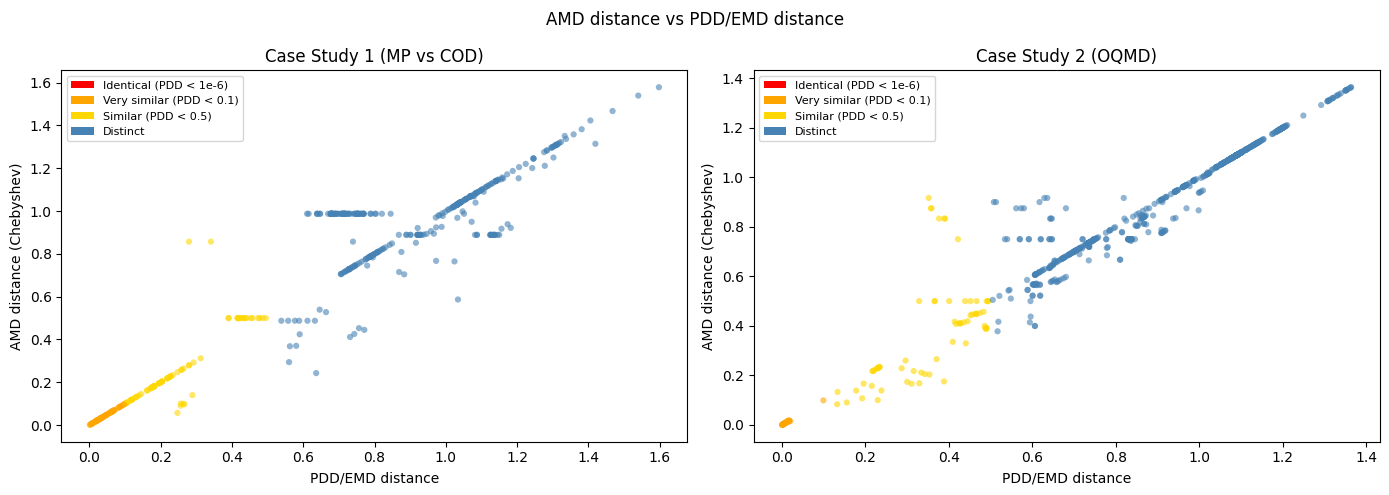

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [
    (axes[0], cs1_df, 'Case Study 1 (MP vs COD)'),
    (axes[1], cs2_df, 'Case Study 2 (OQMD)'),
]:
    colors = df['pdd_emd'].apply(
        lambda x: 'red' if x < 1e-6 else ('orange' if x < 0.1 else ('gold' if x < 0.5 else 'steelblue'))
    )
    ax.scatter(df['pdd_emd'], df['amd_dist'], c=colors, alpha=0.6, s=20, edgecolors='none')
    ax.set_xlabel('PDD/EMD distance')
    ax.set_ylabel('AMD distance (Chebyshev)')
    ax.set_title(title)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red',      label='Identical (PDD < 1e-6)'),
        Patch(facecolor='orange',   label='Very similar (PDD < 0.1)'),
        Patch(facecolor='gold',     label='Similar (PDD < 0.5)'),
        Patch(facecolor='steelblue',label='Distinct'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)

plt.suptitle('AMD distance vs PDD/EMD distance', fontsize=12)
plt.tight_layout()
plt.show()

---
## Save results

In [ ]:
output_dir = Path('results')
output_dir.mkdir(exist_ok=True)

cs1_df.to_csv(output_dir / 'case_study_1_mp_vs_cod_pairwise.csv', index=False)
cs2_df.to_csv(output_dir / 'case_study_2_oqmd_pairwise.csv', index=False)
diversity_df.to_csv(output_dir / 'case_study_2_oqmd_diversity_ranking.csv', index=False)

with open(output_dir / 'case_study_1_raw_result.json', 'w') as fh:
    json.dump(cs1_result, fh, indent=2)

with open(output_dir / 'case_study_2_raw_result.json', 'w') as fh:
    json.dump(cs2_result, fh, indent=2)

print('Results saved to:', output_dir.resolve())

Results saved to: /home/soe/EMOS/Features/Materials_Exploration/AmdScreening/analysis/results
